In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Export Process (2).csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())
print("\nDataset information:")
df.info()

Dataset loaded successfully. Displaying the first 5 rows:


,Data Source,Time,Value
0,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,2026-04-05 07:39:21.05101,0.000000
1,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,2026-04-05 07:39:26.082001,18.258915
2,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,2026-04-05 07:39:31.06601,190.994568
3,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,2026-04-05 07:39:36.082001,318.473053
4,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,2026-04-05 07:39:41.06601,50.348270



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data Source  10800 non-null  object 
 1   Time         10800 non-null  object 
 2   Value        10800 non-null  float64
dtypes: float64(1), object(2)
memory usage: 253.3+ KB


## Data Cleaning

Now, let's clean the dataset by handling missing values and duplicates, converting the timestamp column, and sorting the data chronologically.

In [2]:
# 1. Handle missing values
print(f"Number of missing values before cleaning:\n{df.isnull().sum()}")
# For simplicity, we'll drop rows with any missing values.
# A more sophisticated approach might involve imputation based on column type or domain knowledge.
df.dropna(inplace=True)
print(f"\nNumber of missing values after dropping rows:\n{df.isnull().sum()}")

# 2. Handle duplicates
print(f"\nNumber of duplicate rows before cleaning: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of missing values before cleaning:
Data Source    0
Time           0
Value          0
dtype: int64

Number of missing values after dropping rows:
Data Source    0
Time           0
Value          0
dtype: int64

Number of duplicate rows before cleaning: 0
Number of duplicate rows after dropping: 0


In [4]:
# 3. Convert timestamp to datetime
# Assuming the timestamp column is named 'timestamp'
# If the column name is different, it needs to be adjusted here.
# Let's inspect the columns to find the timestamp column.

# Dynamically find a column that looks like a timestamp, or assume a common name
timestamp_col = None
possible_ts_cols = ['timestamp', 'date', 'time', 'datetime', 'Date & Time', 'Time'] # Added 'Time'
for col in possible_ts_cols:
    if col in df.columns:
        timestamp_col = col
        break

if timestamp_col:
    print(f"Converting column '{timestamp_col}' to datetime format...")
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
    # Drop rows where timestamp conversion failed
    df.dropna(subset=[timestamp_col], inplace=True)
    print(f"'{timestamp_col}' column converted. Displaying info:")
    df.info()
else:
    print("Could not find a suitable timestamp column. Please verify the column name in your dataset.")

# 4. Sort chronologically
if timestamp_col:
    df.sort_values(by=timestamp_col, inplace=True)
    print("\nDataset sorted chronologically by timestamp. Displaying first 5 rows after sorting:")
    display(df.head())
else:
    print("Cannot sort chronologically as no timestamp column was identified.")

Converting column 'Time' to datetime format...
'Time' column converted. Displaying info:
<class 'pandas.core.frame.DataFrame'>
Index: 10789 entries, 0 to 10799
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data Source  10789 non-null  object        
 1   Time         10789 non-null  datetime64[ns]
 2   Value        10789 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 337.2+ KB

Dataset sorted chronologically by timestamp. Displaying first 5 rows after sorting:


,Data Source,Time,Value
7200,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01,2026-04-05 07:21:00.045013,93390.0
3600,\\pisystem-malaysia\TRMT_AM1060ML60_QQIT,2026-04-05 07:21:00.057007,187000.0
7201,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01,2026-04-05 07:22:00.040008,93390.0
3601,\\pisystem-malaysia\TRMT_AM1060ML60_QQIT,2026-04-05 07:22:00.083008,187000.0
7202,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01,2026-04-05 07:23:00.034012,93390.0


## Exploratory Data Analysis (EDA)

Let's visualize the trends in the data, focusing on the 'Value' over 'Time' for each 'Data Source'.

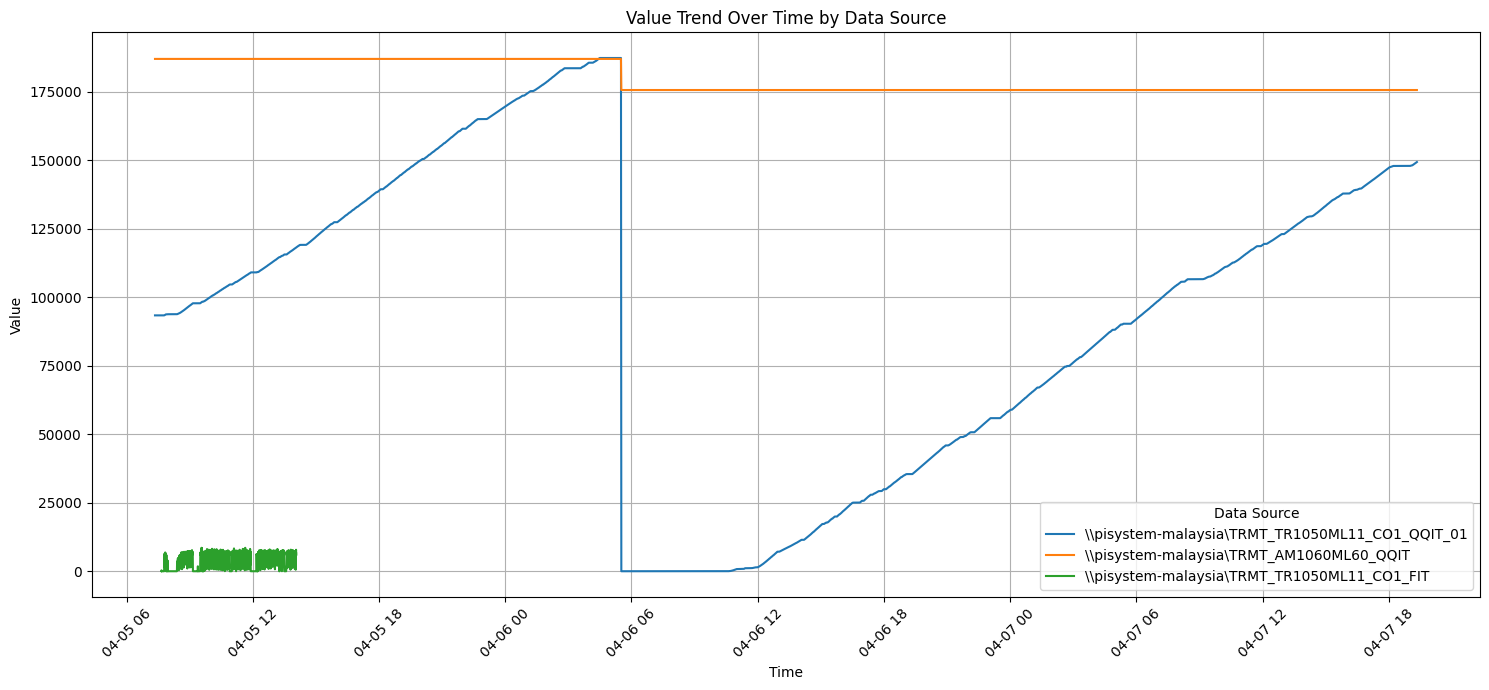

In [5]:
# Visualize 'Value' over 'Time' for each 'Data Source'
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='Time', y='Value', hue='Data Source')
plt.title('Value Trend Over Time by Data Source')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

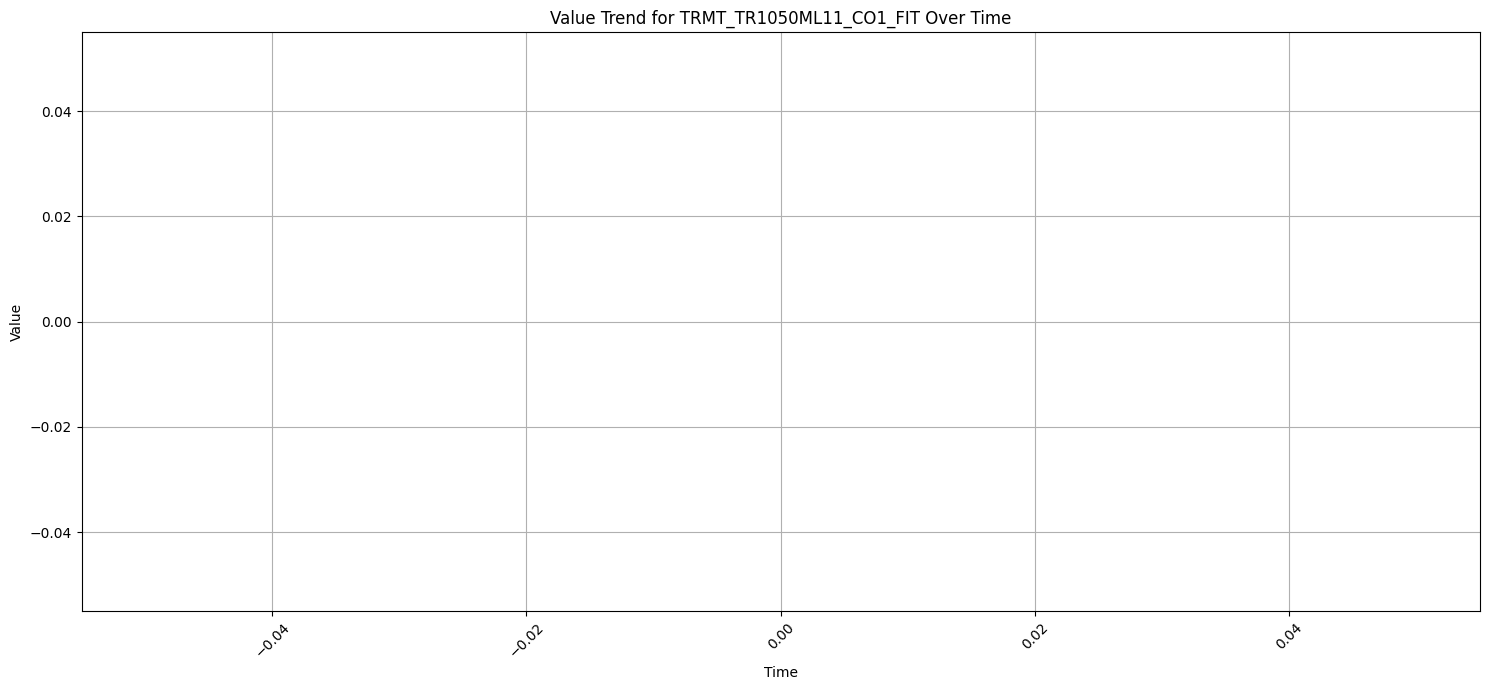

In [8]:
# Filter data for 'TRMT_TR1050ML11_CO1_FIT'
fit_data = df[df['Data Source'] == r'\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT']

# Plot the trend for this specific data source
plt.figure(figsize=(15, 7))
sns.lineplot(data=fit_data, x='Time', y='Value')
plt.title('Value Trend for TRMT_TR1050ML11_CO1_FIT Over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

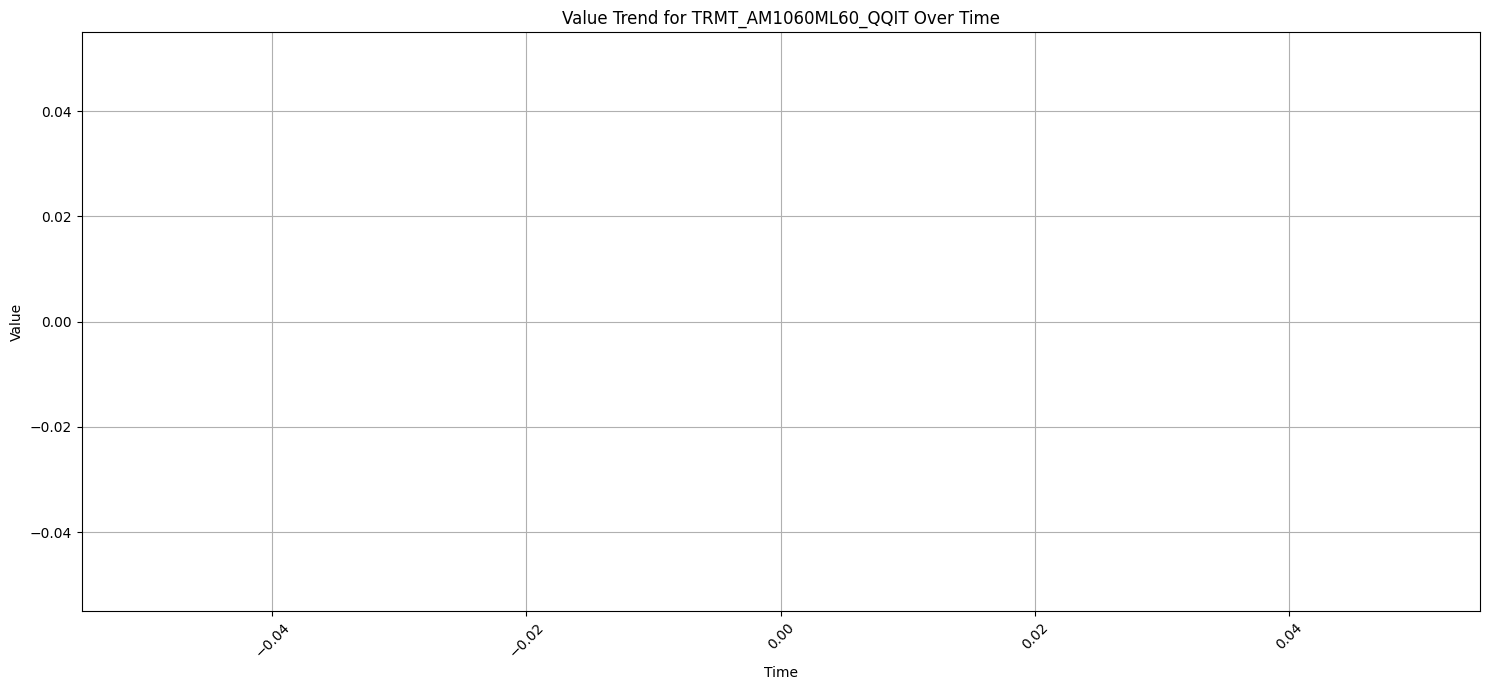

In [9]:
# Filter data for '\pisystem-malaysia\TRMT_AM1060ML60_QQIT'
qqit_data = df[df['Data Source'] == r'\\pisystem-malaysia\\TRMT_AM1060ML60_QQIT']

# Plot the trend for this specific data source
plt.figure(figsize=(15, 7))
sns.lineplot(data=qqit_data, x='Time', y='Value')
plt.title('Value Trend for TRMT_AM1060ML60_QQIT Over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print('Unique Data Source values in the dataset:')
print(df['Data Source'].unique())

Unique Data Source values in the dataset:
['\\\\pisystem-malaysia\\TRMT_TR1050ML11_CO1_QQIT_01'
 '\\\\pisystem-malaysia\\TRMT_AM1060ML60_QQIT'
 '\\\\pisystem-malaysia\\TRMT_TR1050ML11_CO1_FIT']


### Correlation Analysis between Data Sources

To understand the relationships between the 'Value' of different data sources, we'll calculate the correlation matrix. First, we need to pivot the data so that each `Data Source` becomes a column, with `Time` as the index and `Value` as the corresponding entry.

In [10]:
# Pivot the DataFrame to have 'Data Source' as columns and 'Time' as index
df_pivot = df.pivot_table(index='Time', columns='Data Source', values='Value')
display(df_pivot.head())

# Calculate the correlation matrix
correlation_matrix = df_pivot.corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

Data Source,\\pisystem-malaysia\TRMT_AM1060ML60_QQIT,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01
Time,,,
2026-04-05 07:21:00.045013,NaN,NaN,93390.0
2026-04-05 07:21:00.057007,187000.0,NaN,NaN
2026-04-05 07:22:00.040008,NaN,NaN,93390.0
2026-04-05 07:22:00.083008,187000.0,NaN,NaN
2026-04-05 07:23:00.034012,NaN,NaN,93390.0



Correlation Matrix:


Data Source,\\pisystem-malaysia\TRMT_AM1060ML60_QQIT,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01
Data Source,,,
\\pisystem-malaysia\TRMT_AM1060ML60_QQIT,1.000000,NaN,0.486814
\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT,NaN,1.0,NaN
\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01,0.486814,NaN,1.000000


### Visualizing the Correlation Matrix

A heatmap provides a clear visual representation of the correlation coefficients between the different data sources. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation.

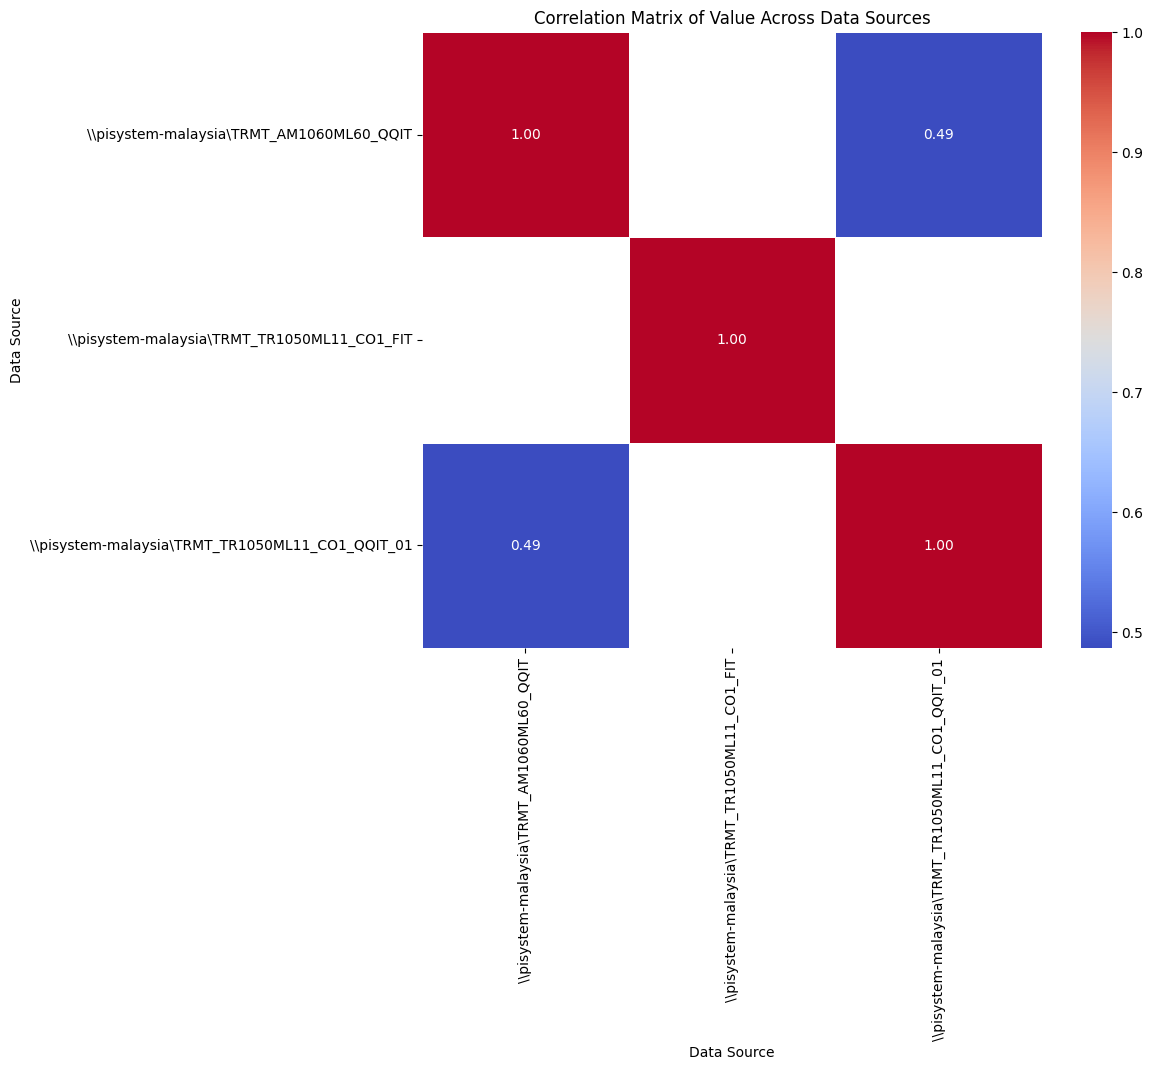

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Value Across Data Sources')
plt.show()

## Shift Analysis

To analyze performance differences and detect events based on shifts, we first need to define the shifts based on the 'Time' column. We will categorize data into a day shift (07:00–19:00) and a night shift (19:00–07:00).

In [14]:
def get_shift(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 19:
        return 'Day Shift'
    else:
        return 'Night Shift'

df['Shift'] = df['Time'].apply(get_shift)
print('Shift distribution:')
print(df['Shift'].value_counts())

Shift distribution:
Shift
Day Shift      7869
Night Shift    2920
Name: count, dtype: int64


## Compare Performance Between Shifts

Now that the data is segmented by shift, we can compare the 'Value' between the day and night shifts. We'll use a box plot to visualize the distribution of 'Value' for each shift and calculate descriptive statistics.

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Shift', y='Value', palette='viridis')
plt.title('Value Distribution by Shift')
plt.xlabel('Shift')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nDescriptive statistics of 'Value' by Shift:")
display(df.groupby('Shift')['Value'].describe())

## Downtime Detection and OEE-like Metric

To proceed with detecting downtime events (e.g., zero tonnage) and calculating an OEE-like metric, it is crucial to know which 'Data Source' corresponds to 'tonnage', 'belt speed', 'motor current', or other relevant metrics you wish to include.

Could you please provide the mapping of your `Data Source` values to these physical metrics?

*   `\\pisystem-malaysia\TRMT_TR1050ML11_CO1_QQIT_01`
*   `\\pisystem-malaysia\TRMT_AM1060ML60_QQIT`
*   `\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT`


### 1. Downtime Detection (Zero Tonnage)
We will define downtime as periods where the `FIT` (Flow Indicator Transmitter) value is zero or very close to it, indicating no material is being exported.

Downtime Percentage by Shift (%):


is_downtime,False,True
Shift,,
Day Shift,99.387698,0.612302


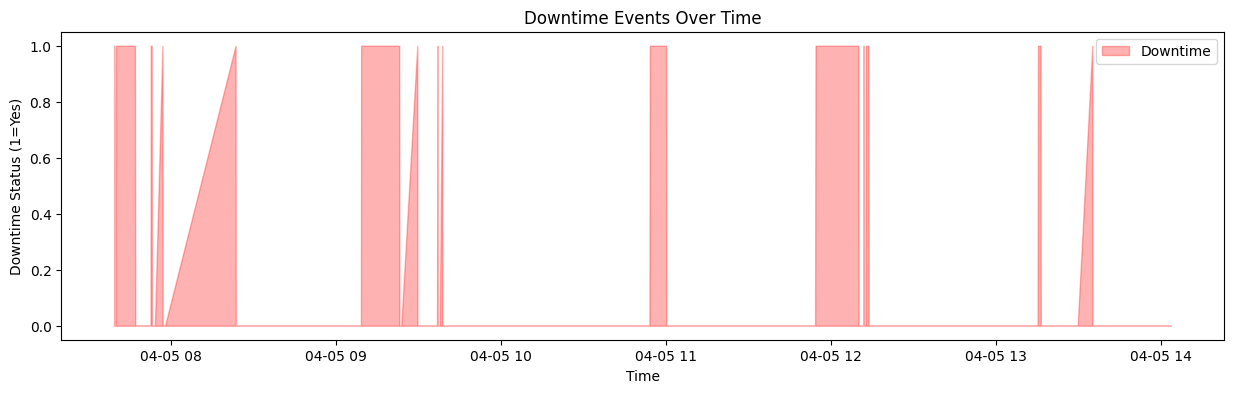

In [15]:
ton_source = r'\\pisystem-malaysia\TRMT_TR1050ML11_CO1_FIT'
ton_df = df[df['Data Source'] == ton_source].copy()
ton_df['is_downtime'] = ton_df['Value'] <= 0.1

downtime_summary = ton_df.groupby('Shift')['is_downtime'].value_counts(normalize=True).unstack() * 100
print('Downtime Percentage by Shift (%):')
display(downtime_summary)

plt.figure(figsize=(15, 4))
plt.fill_between(ton_df['Time'], ton_df['is_downtime'], color='red', alpha=0.3, label='Downtime')
plt.title('Downtime Events Over Time')
plt.xlabel('Time')
plt.ylabel('Downtime Status (1=Yes)')
plt.legend()
plt.show()

### 2. OEE-like Metric Calculation
We will approximate OEE using two components:
- **Availability**: Time performing / Total Scheduled Time
- **Performance**: Actual Tonnage / Maximum observed Tonnage during that period

In [16]:
shift_metrics = ton_df.groupby('Shift').agg(
    total_records=('Value', 'count'),
    running_records=('is_downtime', lambda x: (~x).sum()),
    avg_value=('Value', 'mean'),
    max_value=('Value', 'max')
)

shift_metrics['Availability'] = shift_metrics['running_records'] / shift_metrics['total_records']
running_avg = ton_df[ton_df['is_downtime'] == False].groupby('Shift')['Value'].mean()
shift_metrics['Performance'] = running_avg / shift_metrics['max_value']
shift_metrics['OEE_Index'] = shift_metrics['Availability'] * shift_metrics['Performance']

print('Conveyor Performance (OEE-like) Metrics:')
display(shift_metrics[['Availability', 'Performance', 'OEE_Index']])

Conveyor Performance (OEE-like) Metrics:


,Availability,Performance,OEE_Index
Shift,,,
Day Shift,0.993877,0.584518,0.580939


## Belt Scale Tonnage Analysis

Since this data is strictly from the belt scale, we will analyze the flow distribution and identify peak performance intervals.

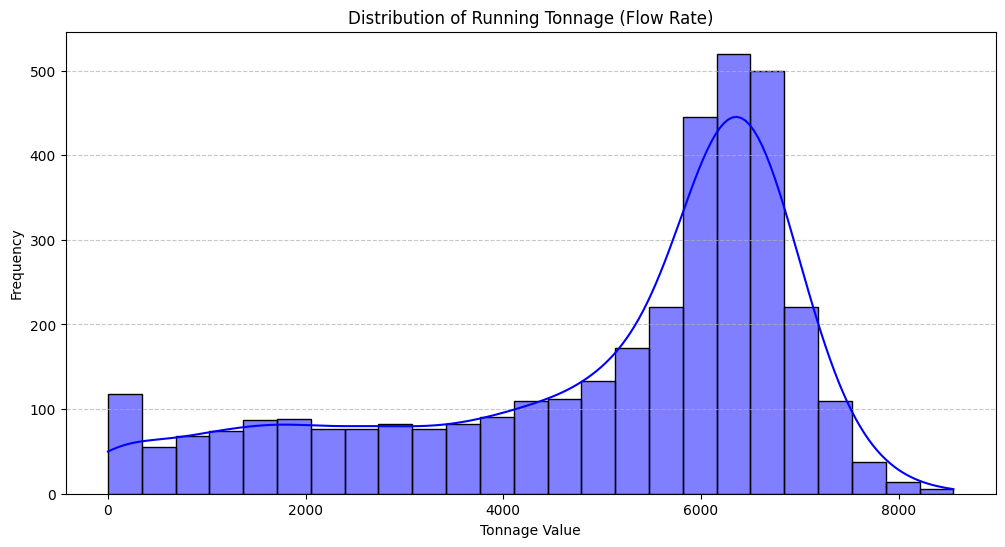

Tonnage Statistics (during running periods):
count    3571.000000
mean     4999.929303
std      2043.204790
min         0.102029
25%      3800.723511
50%      5885.065918
75%      6493.164551
max      8553.942383
Name: Value, dtype: float64


In [17]:
# Analyze the distribution of non-zero tonnage
running_tonnage = ton_df[ton_df['Value'] > 0.1]['Value']

plt.figure(figsize=(12, 6))
sns.histplot(running_tonnage, kde=True, color='blue')
plt.title('Distribution of Running Tonnage (Flow Rate)')
plt.xlabel('Tonnage Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Tonnage Statistics (during running periods):")
print(running_tonnage.describe())

### Hourly Average Tonnage
Let's look at how the average tonnage fluctuates throughout the day to identify peak usage hours.

/tmp/ipykernel_3746/2715521355.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ton_df_hourly = ton_df.set_index('Time').resample('H')['Value'].mean().reset_index()


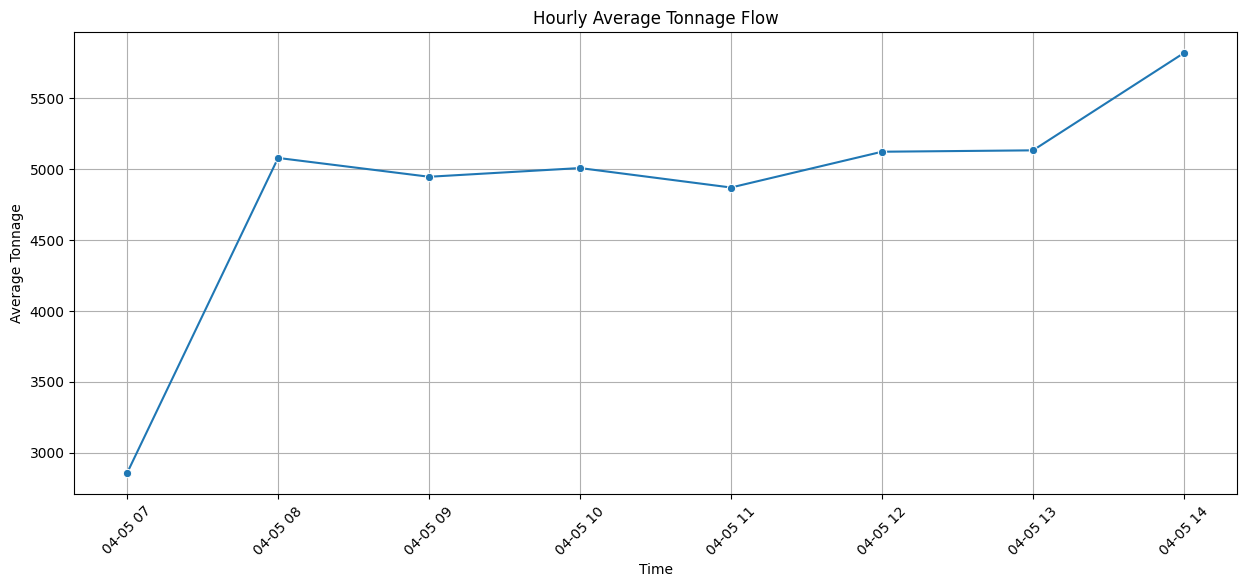

In [18]:
# Resample to hourly averages to see trends
ton_df_hourly = ton_df.set_index('Time').resample('H')['Value'].mean().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=ton_df_hourly, x='Time', y='Value', marker='o')
plt.title('Hourly Average Tonnage Flow')
plt.xlabel('Time')
plt.ylabel('Average Tonnage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Top 5 Peak Throughput Hours

We will now identify the specific hours where the average tonnage was at its highest.

In [19]:
# Sort hourly data to find top 5 peaks
top_5_peaks = ton_df_hourly.sort_values(by='Value', ascending=False).head(5)

print("Top 5 Peak Throughput Hours:")
display(top_5_peaks)

Top 5 Peak Throughput Hours:


,Time,Value
7,2026-04-05 14:00:00,5816.475273
6,2026-04-05 13:00:00,5130.160377
5,2026-04-05 12:00:00,5120.395495
1,2026-04-05 08:00:00,5076.634406
3,2026-04-05 10:00:00,5005.329952
